# Import Functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
from tqdm.notebook import tqdm

import sys
sys.path.append('libsvm-3.17/python') # This notebook should be in the same level as the libsvm package to work
import svmutil as su # this python file is inside libsvm-3.17/python

# Perceptron Classifier Construction

## Generate Synthetic Data for testing Perceptron Classifier
A normally distributed dataset which can be separated linearly will generated to test the effectivity of the perceptron classifier.

In [2]:
def generate_data(mu, sigma, size, y_class=1, train_n=50, seed=42):
    """Generate 2D random normal data."""
    rng = np.random.RandomState(seed)
    X = rng.multivariate_normal(mu, sigma, size)
    y = np.array([y_class] * size)

    X_train = X[:train_n,:]
    X_test = X[train_n:, :]
    y_train = y[:train_n]
    y_test = y[train_n:]

    return X_train, X_test, y_train, y_test

Generate the synthetic data for the negative class.

In [3]:
Xn1_train, Xn1_test, yn1_train, yn1_test = generate_data(
    mu=np.array([0, 0]).T,
    sigma=np.eye(2),
    size=100,
    y_class=-1,
    seed=42
)

Generate the synthetic data for the positive class.

In [4]:
Xp1_train, Xp1_test, yp1_train, yp1_test = generate_data(
    mu=np.array([10, 10]).T,
    sigma=np.eye(2),
    size=100,
    y_class=1,
    seed=56
)

Merge the 2 classes.

In [5]:
X_train = np.r_[Xn1_train, Xp1_train]
X_test = np.r_[Xn1_test, Xp1_test]
y_train = np.r_[yn1_train, yp1_train]
y_test = np.r_[yn1_test, yp1_test]

A 2D scatter plot of the training dataset.

<Axes: >

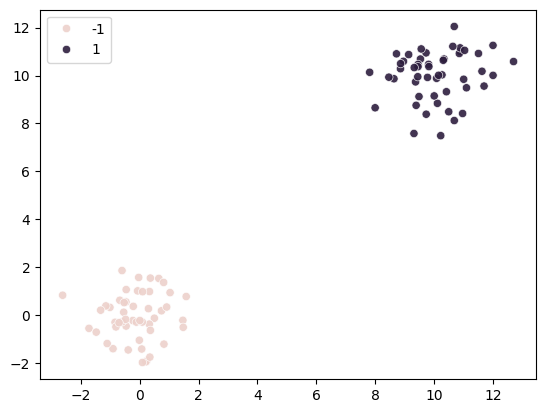

In [6]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=0.9)

## Pocket Algorithm

The pocket algorithm will be implemented using numpy. The model will be trained by updating the weights based on the highest consecutive correct.

In [7]:
def add_bias(X):
    """Helper function that adds a bias feature to a dataset."""
    return np.c_[np.ones(X.shape[0]), X]

def classify(X, y, maxitercnt=10000, seed=42):
    """Implements a perceptron classifier using the pocket algorithm. Returns
    the weights that give the most"""
    N, d = X.shape
    X = add_bias(X)

    itercnt = 0
    nv = 0
    nw = 0
    v = np.zeros(d + 1)
    w = np.zeros(d + 1) 

    rng = np.random.RandomState(seed)
    while itercnt < maxitercnt:
        j = rng.randint(N)
        Xj, yj = X[j], y[j] 
        uj = 1 if v @ Xj >= 0 else -1

        # if correct, add 1
        if uj * yj > 0:
            nv += 1
        
        # if incorrect, if highest consecutive correct, update weight
        elif uj * yj < 0:
            if nv > nw:
                w = v
                nw = nv
                v = v + yj * Xj
                nv = 0
        itercnt += 1
    return w

def predict(X, w):
    """Predict the class of a given data."""
    return np.sign(w @ add_bias(X).T)

def sse(y_true, y_pred):
    """Compute for the sum of squared errors."""
    e = y_true != y_pred
    e2 = np.square(e)
    return np.sum(e2)


def training_error(X, X_train, y, y_train, wt):
    """Compute for the training error."""
    w = classify(X_train, y_train)
    y_pred = predict(X, w)
    error = wt @ (y_pred != y)
    return error
    

As shown here, using the weights trained from the perceptron classifier that uses the pocket algorithm, there are only 6 squared errors (which is equivalent to 6 errors since errors here are 1).

In [8]:
w = classify(X_train, y_train)
y_pred = predict(X_test, w)
sse(y_test, y_pred)

6

# Adaboost

## Banana Dataset

In [9]:
data = np.genfromtxt('banana_data.csv', delimiter=',')
y = data[:, 0]
X = data[:, 1:]

As shown in the scatterplot of the banana dataset, it can be understood where the dataset's name is taken.

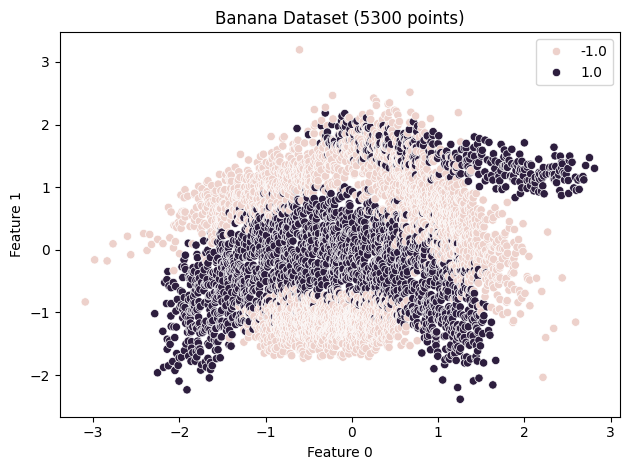

In [10]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, alpha=1)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Banana Dataset (5300 points)')
plt.tight_layout()

In [11]:
def train_test_split(X, y, train_size, seed=42):
    """Split data into train and test."""
    rng = np.random.RandomState(seed)
    train_idx = rng.choice(range(0, y.shape[0]), train_size, replace=False)
    test_idx = np.delete(range(0, y.shape[0]), train_idx)

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_test, y_test

Getting only 400 points from the dataset and letting those be the training points (with the remaining 4900 be the testing points). From its scatterplot, based on human perception, the general distribution of the dataset can already be understood.

In [12]:
X_train, y_train, X_test, y_test = train_test_split(X, y, train_size=400)

<Axes: >

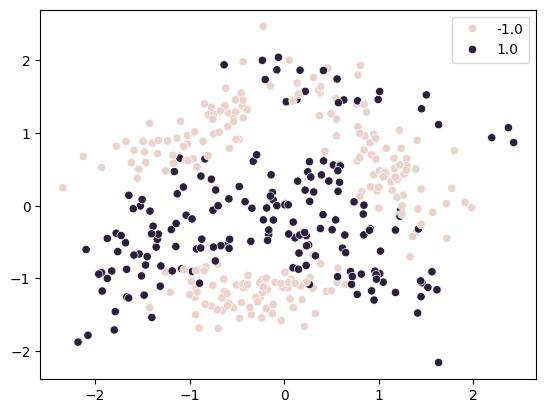

In [13]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=1)

<Axes: >

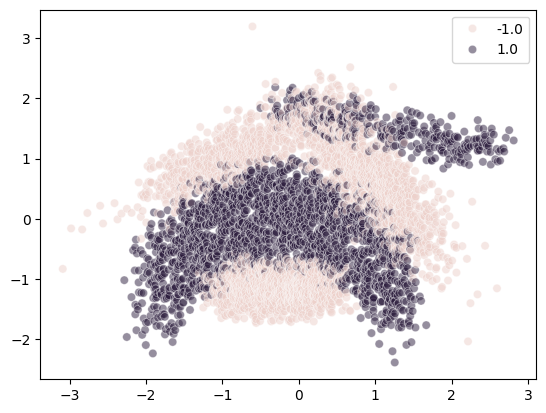

In [14]:
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test, alpha=0.5)

## Save Banana Train and Test as libsvm

Note that scikit-learn is only used to save the file as a .libsvm file. No other uses of scikit-learn aside from this.

In [15]:
from sklearn.datasets import dump_svmlight_file

dump_svmlight_file(X_train, y_train, 'banana_train.libsvm')
dump_svmlight_file(X_test, y_test, 'banana_test.libsvm')

## Splice Dataset

Due to the splice dataset having 60 features, visualization cannot be performed without using other techniques (e.g. dimensionality reduction techniques).

Additionally, dataset was taken here.

https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html#splice

Classes of the training and test dataset seems balanced enough.

In [16]:
datas = np.genfromtxt('splice_data.csv', delimiter=',')
ys_train = datas[:, 0]
Xs_train = datas[:, 1:]

In [17]:
np.unique(ys_train, return_counts=True)

(array([-1.,  1.]), array([483, 517], dtype=int64))

In [18]:
datas = np.genfromtxt('splice_data_test.csv', delimiter=',')
ys_test = datas[:, 0]
Xs_test = datas[:, 1:]


In [19]:
np.unique(ys_test, return_counts=True)

(array([-1.,  1.]), array([1044, 1131], dtype=int64))

## Construction/Implementation

In [20]:
def adabtrain(X, y, K, seed=42, train_subset_size=None):
    """Uses a perceptron classifier as a weak learner."""
    if X.shape[0] != y.shape[0]:
        raise ValueError('{X.shape[0]} does not match {y.shape[0]}')
    
    N = y.shape[0]
    wt = np.full(N, fill_value=1/N)

    if not train_subset_size:
        train_subset_size = N
    
    hs = []
    alpha_coefs = []

    rng = np.random.RandomState(seed)

    for _ in range(K):
        t_idx = rng.choice(
            np.arange(0, N), 
            train_subset_size, 
            replace=False, 
            p=wt
        )
        X_t, y_t = X[t_idx], y[t_idx]

        # uses Perceptron Classifier
        w = classify(X_t, y_t)
        h = predict(X, w)

        et = wt @ (h != y)
        et = np.clip(et, 1e-10, 1 - 1e-10) # avoid division by zero

        alpha_coef = 0.5 * np.log((1-et)/et)
        
        wt = wt * np.exp(-alpha_coef * y * h)
        wt = wt/np.sum(wt)

        hs.append(w)
        alpha_coefs.append(alpha_coef)

    hs = np.array(hs)
    alpha_coefs = np.array(alpha_coefs)

    return hs, alpha_coefs
    
def adabpredict(X, y, hs, alpha_coefs):
    """Performs predictions based on the weights and alpha coefficients."""
    hypothesis = np.array([predict(X, w) for w in hs])
    predictions = np.sign(alpha_coefs @ hypothesis)
    return predictions

def accuracy(y_true, y_pred):
    """Computes for the accuracy."""
    return np.mean(y_true == y_pred)

## Evaluation Banana

In [21]:
t1 = time.time()
kmax = 1000
hs, alpha_coefs = adabtrain(X_train, y_train, kmax)
traintime1 = time.time() - t1
print(f'Train time for Adaboost (banana) {traintime1} seconds')

Train time for Adaboost (banana) 39.69359302520752 seconds


In [22]:
t1 = time.time()
y_test_pred = adabpredict(X_test, y_test, hs, alpha_coefs)
testtime1 = time.time() - t1
print(f'Test time for Adaboost (banana): {testtime1} seconds')

Test time for Adaboost (banana): 0.20742416381835938 seconds


In [23]:
acc_train_list = []
acc_test_list = []
interval = 10
for k in tqdm(range(10, 1000+interval, interval), desc='K', unit='10k'):
    hs_, alpha_coefs_ = hs[:k], alpha_coefs[:k]
    y_train_pred = adabpredict(X_train, y_train, hs_, alpha_coefs_)
    y_test_pred = adabpredict(X_test, y_test, hs_, alpha_coefs_)

    acc_train = accuracy(y_train, y_train_pred)
    acc_test = accuracy(y_test, y_test_pred)

    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

K:   0%|          | 0/100 [00:00<?, ?10k/s]

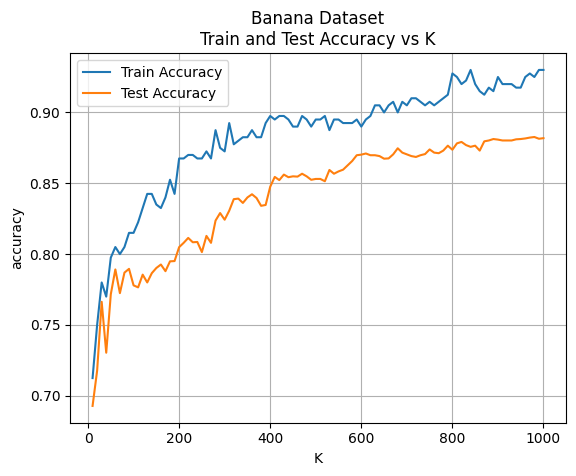

In [24]:
acc_train_array = np.array(acc_train_list)
acc_test_array = np.array(acc_test_list)
x = np.arange(10, 1010, 10)

plt.plot(x, acc_train_array, label='Train Accuracy')
plt.plot(x, acc_test_array, label='Test Accuracy')
plt.xlabel('K')
plt.ylabel('accuracy')
plt.legend()
plt.title('Banana Dataset\nTrain and Test Accuracy vs K')
plt.grid()

In [25]:
# Accuracy at k=1000
trainacc1 = acc_train_array[-1] * 100
testacc1 = acc_test_array[-1] * 100
print(f'Train Accuracy at K = 1000 for Banana dataset is: {trainacc1:.4f}')
print(f'Test Accuracy at K = 1000 for Banana dataset is: {testacc1:.4f}')

Train Accuracy at K = 1000 for Banana dataset is: 93.0000
Test Accuracy at K = 1000 for Banana dataset is: 88.1837


## Evaluation Splice

In [26]:
t1 = time.time()
kmax = 1000
hs, alpha_coefs = adabtrain(Xs_train, ys_train, kmax)
traintime2 = time.time() - t1
print(f'Train time for Adaboost (splice) {traintime2} seconds')

Train time for Adaboost (splice) 40.4366888999939 seconds


In [27]:
t1 = time.time()
y_test_pred = adabpredict(Xs_test, ys_test, hs, alpha_coefs)
testtime2 = time.time() - t1
print(f'Test time for Adaboost (splice) {testtime2} seconds')

Test time for Adaboost (splice) 0.43584513664245605 seconds


In [28]:
acc_train_list = []
acc_test_list = []
interval = 10
for k in tqdm(range(10, 1000+interval, interval), desc='K', unit='10k'):
    hs_, alpha_coefs_ = hs[:k], alpha_coefs[:k]
    y_train_pred = adabpredict(Xs_train, ys_train, hs_, alpha_coefs_)
    y_test_pred = adabpredict(Xs_test, ys_test, hs_, alpha_coefs_)

    acc_train = accuracy(ys_train, y_train_pred)
    acc_test = accuracy(ys_test, y_test_pred)

    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

K:   0%|          | 0/100 [00:00<?, ?10k/s]

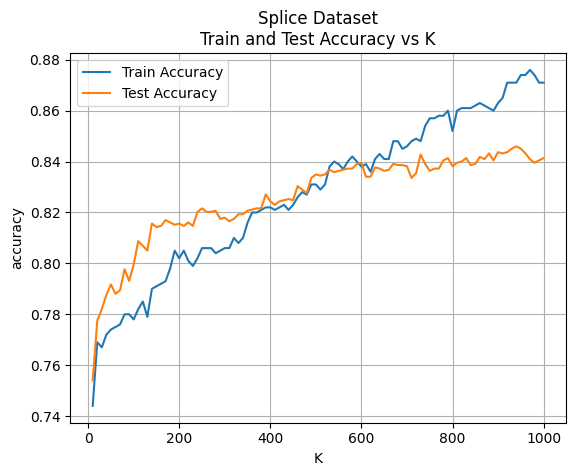

In [29]:
acc_train_array = np.array(acc_train_list)
acc_test_array = np.array(acc_test_list)
x = np.arange(10, 1010, 10)

plt.plot(x, acc_train_array, label='Train Accuracy')
plt.plot(x, acc_test_array, label='Test Accuracy')
plt.xlabel('K')
plt.ylabel('accuracy')
plt.legend()
plt.title('Splice Dataset\nTrain and Test Accuracy vs K')
plt.grid()

In [30]:
# Accuracy at k=1000
trainacc2 = acc_train_array[-1] * 100
testacc2 = acc_test_array[-1] * 100
print(f'Train Accuracy at K = 1000 for Spline dataset is: {trainacc2:.4f}')
print(f'Test Accuracy at K = 1000 for Spline dataset is: {testacc2:.4f}')

Train Accuracy at K = 1000 for Spline dataset is: 87.1000
Test Accuracy at K = 1000 for Spline dataset is: 84.1379


# SVM Classifier

## Banana SVM

In [31]:
# Pull the banana train and test libsvm file
y_b_train, X_b_train = su.svm_read_problem('banana_train.libsvm')
y_b_test, X_b_test = su.svm_read_problem('banana_test.libsvm')

In [32]:
C_values = [2**i for i in range(-5, 15, 2)]
gamma_values = [2**i for i in range(-15, 3, 2)]
kernel_types = [0, 1, 2, 3] # linear, poly, rbf, sigmoid

best_acc = 0
best_params_b = {}

t1 = time.time()
for t in kernel_types:
    for C in C_values:
        if t in [1, 2, 3]:
            for gamma in gamma_values:
                param_str = f'-s 0 -t {t} -c {C} -g {gamma} -v 5 -q' 
                acc = su.svm_train(y_b_train, X_b_train, param_str)
                print(f'Kernel={t}, C={C}, gamma={gamma} -> Acc.: {acc}%')

                if acc > best_acc:
                    best_acc = acc
                    best_params_b = {'t': t, 'C': C, 'gamma': gamma}
        else:
            param_str = f'-s 0 -t {t} -c {C} -v 5 -q' 
            acc = su.svm_train(y_b_train, X_b_train, param_str)
            print(f'Kernel={t}, C={C} -> Acc.: {acc}%')

            if acc > best_acc:
                best_acc = acc
                best_params_b = {'t': t, 'C': C}
optitime3 = time.time() - t1

print(f"Kernel={best_params_b['t']}, C={best_params_b['C']}, " +
      (f"gamma={best_params_b['gamma']}" if 'gamma' in best_params_b else "no gamma"))
print(f"Best CV Accuracy = {best_acc:.2f}%")

Cross Validation Accuracy = 55.5%
Kernel=0, C=0.03125 -> Acc.: 55.5%
Cross Validation Accuracy = 55.5%
Kernel=0, C=0.125 -> Acc.: 55.5%
Cross Validation Accuracy = 52.25%
Kernel=0, C=0.5 -> Acc.: 52.25%
Cross Validation Accuracy = 49.5%
Kernel=0, C=2 -> Acc.: 49.5%
Cross Validation Accuracy = 51%
Kernel=0, C=8 -> Acc.: 51.0%
Cross Validation Accuracy = 55.5%
Kernel=0, C=32 -> Acc.: 55.5%
Cross Validation Accuracy = 50.75%
Kernel=0, C=128 -> Acc.: 50.75%
Cross Validation Accuracy = 51.75%
Kernel=0, C=512 -> Acc.: 51.75%
Cross Validation Accuracy = 55.5%
Kernel=0, C=2048 -> Acc.: 55.5%
Cross Validation Accuracy = 53.5%
Kernel=0, C=8192 -> Acc.: 53.5%
Cross Validation Accuracy = 55.5%
Kernel=1, C=0.03125, gamma=3.0517578125e-05 -> Acc.: 55.5%
Cross Validation Accuracy = 55.5%
Kernel=1, C=0.03125, gamma=0.0001220703125 -> Acc.: 55.5%
Cross Validation Accuracy = 55.5%
Kernel=1, C=0.03125, gamma=0.00048828125 -> Acc.: 55.5%
Cross Validation Accuracy = 55.5%
Kernel=1, C=0.03125, gamma=0.00195

In [33]:
t1 = time.time()
param_str = f"-s 0 -t {best_params_b['t']} -c {best_params_b['C']}"
if 'gamma' in best_params_b:
    param_str += f" -g {best_params_b['gamma']}"

b_model = su.svm_train(y_b_train, X_b_train, param_str)
traintime3 = time.time() - t1
print(f'Train time for SVM (banana) {traintime3} seconds')
su.svm_save_model('banana_best_model.model', b_model)

Train time for SVM (banana) 0.0030715465545654297 seconds


In [34]:
t1 = time.time()
p_label, p_acc, p_val = su.svm_predict(y_b_test, X_b_test, b_model)
testtime3 = time.time() - t1
print(f'Test time for SVM (banana) {testtime3} seconds')

Accuracy = 88.9184% (4357/4900) (classification)
Test time for SVM (banana) 0.030344247817993164 seconds


In [35]:
trainacc3 = su.svm_predict(y_b_train, X_b_train, b_model)[1][0]
testacc3 = su.svm_predict(y_b_test, X_b_test, b_model)[1][0]
print(f'Train Accuracy at {', '.join([f'{k} = {v}' for k, v in best_params_b.items()])} for Banana dataset is: {trainacc3}')
print(f'Test Accuracy at {', '.join([f'{k} = {v}' for k, v in best_params_b.items()])} for Banana dataset is: {testacc3}')

Accuracy = 91% (364/400) (classification)
Accuracy = 88.9184% (4357/4900) (classification)
Train Accuracy at t = 2, C = 8, gamma = 2 for Banana dataset is: 91.0
Test Accuracy at t = 2, C = 8, gamma = 2 for Banana dataset is: 88.91836734693878


## Splice SVM

In [36]:
# Pull the splice train and test libsvm file
y_s_train, X_s_train = su.svm_read_problem('splice_data.libsvm')
y_s_test, X_s_test = su.svm_read_problem('splice_data_test.libsvm')

In [37]:
C_values = [2**i for i in range(-5, 15, 2)]
gamma_values = [2**i for i in range(-15, 3, 2)]
kernel_types = [0, 1, 2, 3] # linear, poly, rbf, sigmoid

best_acc = 0
best_params_s = {}

t1 = time.time()
for t in kernel_types:
    for C in C_values:
        if t in [1, 2, 3]:
            for gamma in gamma_values:
                param_str = f'-s 0 -t {t} -c {C} -g {gamma} -v 5 -q' 
                acc = su.svm_train(y_s_train, X_s_train, param_str)
                print(f'Kernel={t}, C={C}, gamma={gamma} -> Acc.: {acc}%')

                if acc > best_acc:
                    best_acc = acc
                    best_params_s = {'t': t, 'C': C, 'gamma': gamma}
        else:
            param_str = f'-s 0 -t {t} -c {C} -v 5 -q' 
            acc = su.svm_train(y_s_train, X_s_train, param_str)
            print(f'Kernel={t}, C={C} -> Acc.: {acc}%')

            if acc > best_acc:
                best_acc = acc
                best_params_s = {'t': t, 'C': C}
                
optitime4 = time.time() - t1

print(f"Kernel={best_params_s['t']}, C={best_params_s['C']}, " +
      (f"gamma={best_params_s['gamma']}" if 'gamma' in best_params_s else "no gamma"))
print(f"Best CV Accuracy = {best_acc:.2f}%")

Cross Validation Accuracy = 79.9%
Kernel=0, C=0.03125 -> Acc.: 79.9%
Cross Validation Accuracy = 78.8%
Kernel=0, C=0.125 -> Acc.: 78.8%
Cross Validation Accuracy = 79.5%
Kernel=0, C=0.5 -> Acc.: 79.5%
Cross Validation Accuracy = 80.4%
Kernel=0, C=2 -> Acc.: 80.4%
Cross Validation Accuracy = 80.1%
Kernel=0, C=8 -> Acc.: 80.1%
Cross Validation Accuracy = 79.9%
Kernel=0, C=32 -> Acc.: 79.9%
Cross Validation Accuracy = 79.2%
Kernel=0, C=128 -> Acc.: 79.2%
Cross Validation Accuracy = 78.4%
Kernel=0, C=512 -> Acc.: 78.4%
Cross Validation Accuracy = 80.3%
Kernel=0, C=2048 -> Acc.: 80.3%
Cross Validation Accuracy = 67.6%
Kernel=0, C=8192 -> Acc.: 67.6%
Cross Validation Accuracy = 51.7%
Kernel=1, C=0.03125, gamma=3.0517578125e-05 -> Acc.: 51.7%
Cross Validation Accuracy = 51.7%
Kernel=1, C=0.03125, gamma=0.0001220703125 -> Acc.: 51.7%
Cross Validation Accuracy = 51.7%
Kernel=1, C=0.03125, gamma=0.00048828125 -> Acc.: 51.7%
Cross Validation Accuracy = 51.7%
Kernel=1, C=0.03125, gamma=0.001953125

In [38]:
t1 = time.time()
param_str = f"-s 0 -t {best_params_s['t']} -c {best_params_s['C']}"
if 'gamma' in best_params_s:
    param_str += f" -g {best_params_s['gamma']}"

s_model = su.svm_train(y_s_train, X_s_train, param_str)
traintime4 = time.time() - t1
print(f'Train time for SVM (splice) {traintime4} seconds')
su.svm_save_model('splice_best_model.model', s_model)

Train time for SVM (splice) 0.09343552589416504 seconds


In [39]:
t1 = time.time()
p_label, p_acc, p_val = su.svm_predict(y_s_test, X_s_test, s_model)
testtime4 = time.time() - t1
print(f'Test time for SVM (splice) {testtime4} seconds')

Accuracy = 89.7471% (1952/2175) (classification)
Test time for SVM (splice) 0.13407063484191895 seconds


In [40]:
trainacc4 = su.svm_predict(y_s_train, X_s_train, s_model)[1][0]
testacc4 = su.svm_predict(y_s_test, X_s_test, s_model)[1][0]
print(f'Train Accuracy at {', '.join([f'{k} = {v}' for k, v in best_params_s.items()])} for Splice dataset is: {trainacc4}')
print(f'Test Accuracy at {', '.join([f'{k} = {v}' for k, v in best_params_s.items()])} for Splice dataset is: {testacc4}')

Accuracy = 100% (1000/1000) (classification)
Accuracy = 89.7471% (1952/2175) (classification)
Train Accuracy at t = 2, C = 8, gamma = 0.0078125 for Splice dataset is: 100.0
Test Accuracy at t = 2, C = 8, gamma = 0.0078125 for Splice dataset is: 89.74712643678161


# Summary

In [46]:
pd.DataFrame(
    {
        'Train Accuracy (%)': [trainacc1, trainacc3, trainacc2, trainacc4],
        'Test Accuracy (%)': [testacc1, testacc3, testacc2, testacc4],
        'Train Speed (sec)': [traintime1, traintime3, traintime2, traintime4],
        'Test Speed (sec)': [testtime1, testtime3, testtime2, testtime4],
        'Hyperparameter Search Speed (sec)': [traintime1, optitime3, traintime2, optitime4],
    },
    index = [
        'Banana Adaboost',  
        'Banana SVM', 
        'Splice Adaboost',
        'Splice SVM'
    ]
).T.apply(lambda x: round(x, 4))

,Banana Adaboost,Banana SVM,Splice Adaboost,Splice SVM
Train Accuracy (%),93.0000,91.0000,87.1000,100.0000
Test Accuracy (%),88.1837,88.9184,84.1379,89.7471
Train Speed (sec),39.6936,0.0031,40.4367,0.0934
Test Speed (sec),0.2074,0.0303,0.4358,0.1341
Hyperparameter Search Speed (sec),39.6936,127.3918,40.4367,489.9821


In [45]:
# Best params for Banana dataset
print(best_params_b)

# Best params for Splice dataset
print(best_params_s)

{'t': 2, 'C': 8, 'gamma': 2}
{'t': 2, 'C': 8, 'gamma': 0.0078125}


In [43]:
# Adaboost K or number of estimators used for both Banana and Splice Dataset is K=1000.
# SVM Hyperparameters for Banana dataset C=0.5 gamma=2
# SVM Hyperparameters for Splice dataset C=32 gamma=0.0078125